<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
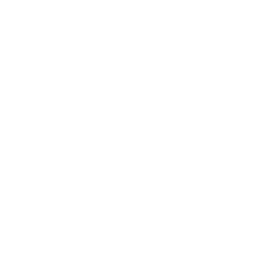
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">臨床試験有害事象コーディング</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 医薬品・ドラッグセーフティ監視 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

有害事象データセットはMedDRA基本語（逐語的な表記）のまま届くが、規制当局向けの安全性テーブルは臓器別大分類（SOC）で整理される。この例では、各基本語をそのSOCにマッピングするPROC FORMATの値書式を構築し、その単一の書式を使ってすべての後続の集計処理を駆動する：SOC×治療群のPROC FREQクロス集計、SOC×重症度の内訳、および重篤有害事象サマリーである。マッピングがこの書式1か所にのみ存在するため、新しいMedDRAバージョンへの再コード化はすべてのレポートを書き直すのではなく、書式を1か所編集するだけで済む。ODS OUTPUTはSOC別頻度を後続のシグナルレビュー用のデータセットとして取得する。


## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------:|
| WORK.AE_RAW | MedDRA基本語を含む合成有害事象レコード | 100 |
| WORK.RANDOMIZATION | 被験者の治療群割り付け | 100 |

この環境はライセンスなしで実行されるため、生成される各テーブルは100観測に制限される。このシナリオはその上限に合わせてサイズ設定されている：腫瘍学試験に典型的な12種類のMedDRAパネルから抽出した100件の有害事象。


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic adverse event dataset
   MedDRA preferred terms mapped to SOC categories
   -------------------------------------------------------- */
データ work.ae_raw;
    長さ aedecod $40 aesev $16;
    呼出 streaminit(42);
    配列 pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    繰返 i = 1 から 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        もし pt_idx = 1 なら aedecod = '悪心';
        他 もし pt_idx = 2 なら aedecod = '頭痛';
        他 もし pt_idx = 3 なら aedecod = '嘔吐';
        他 もし pt_idx = 4 なら aedecod = '下痢';
        他 もし pt_idx = 5 なら aedecod = '咳嗽';
        他 もし pt_idx = 6 なら aedecod = '疲労';
        他 もし pt_idx = 7 なら aedecod = '関節痛';
        他 もし pt_idx = 8 なら aedecod = '発熱';
        他 もし pt_idx = 9 なら aedecod = '腹痛';
        他 もし pt_idx = 10 なら aedecod = '好中球減少症';
        他 もし pt_idx = 11 なら aedecod = '発熱性好中球減少症';
        他 aedecod = '注入に伴う反応';
        sev_idx = int(rand('uniform') * 3) + 1;
        もし pt_idx IN (10, 11) なら sev_idx = MAX(sev_idx, 2);
        もし sev_idx = 1 なら aesev = '軽度';
        他 もし sev_idx = 2 なら aesev = '中等度';
        他 aesev = '重度';
        aeser = ifc(aesev = '重度' かつ rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        もし aestdy > 365 なら aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', PUT(int(rand('uniform') * 25) + 1, z3.));
        出力;
    終了;
    削除 i pt_idx sev_idx;
実行;



NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.80 seconds
  cpu   1.80 seconds


In [2]:
/* --------------------------------------------------------
   Generate subject randomization table
   -------------------------------------------------------- */
データ work.randomization;
    長さ treatment_arm $20;
    呼出 streaminit(43);
    繰返 subject_id = 1 から 800;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        もし arm_idx = 1 なら treatment_arm = '治験薬群';
        他 もし arm_idx = 2 なら treatment_arm = '実薬対照群';
        他 treatment_arm = 'プラセボ群';
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        出力;
    終了;
    削除 arm_idx;
    書式 randomization_date date9.;
実行;



NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                                   有害事象基本語頻度 (未マッピング)                                                   

                                                   The FREQ Procedure

有害事象基本語 (PT)                   Frequency    Percent
----------------------------------------------------
下痢                                    12     12.00
頭痛                                    12     12.00
疲労                                    11     11.00
発熱                                    11     11.00
悪心                                    10     10.00
関節痛                                   10     10.00
注入に伴う反応                                8      8.00
咳嗽                                     7      7.00
好中球減少症                                 5      5.00
発熱性好中球減少症                              5      5.00
腹痛                                     5      5.00
嘔吐                                     4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


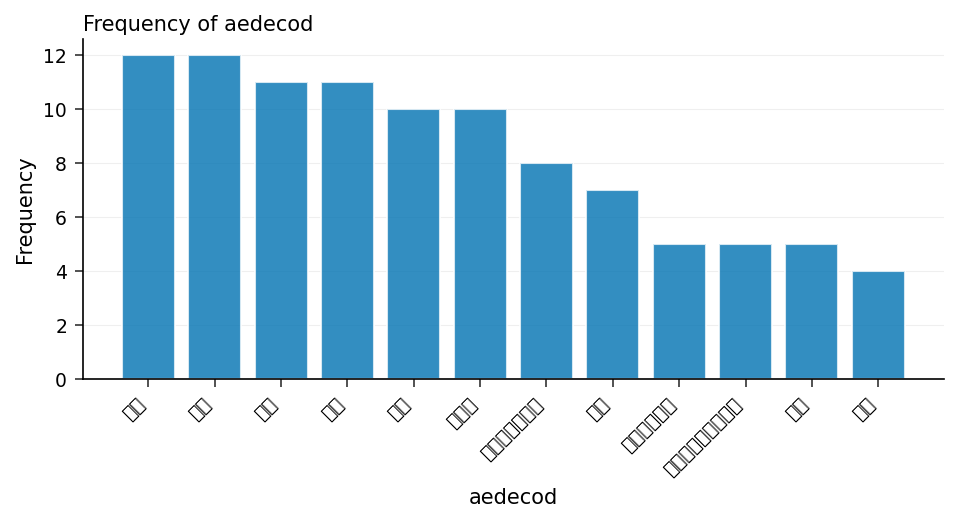

In [3]:
/* --------------------------------------------------------
   Baseline preferred term frequency before SOC mapping
   -------------------------------------------------------- */
処理 度数 データ=work.ae_raw ORDER=度数;
    TABLES aedecod / nocum;
    見出 aedecod = "有害事象基本語 (PT)";
    表題 '有害事象基本語頻度 (未マッピング)';
実行;


---

                                                   有害事象基本語頻度 (未マッピング)                                                   




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


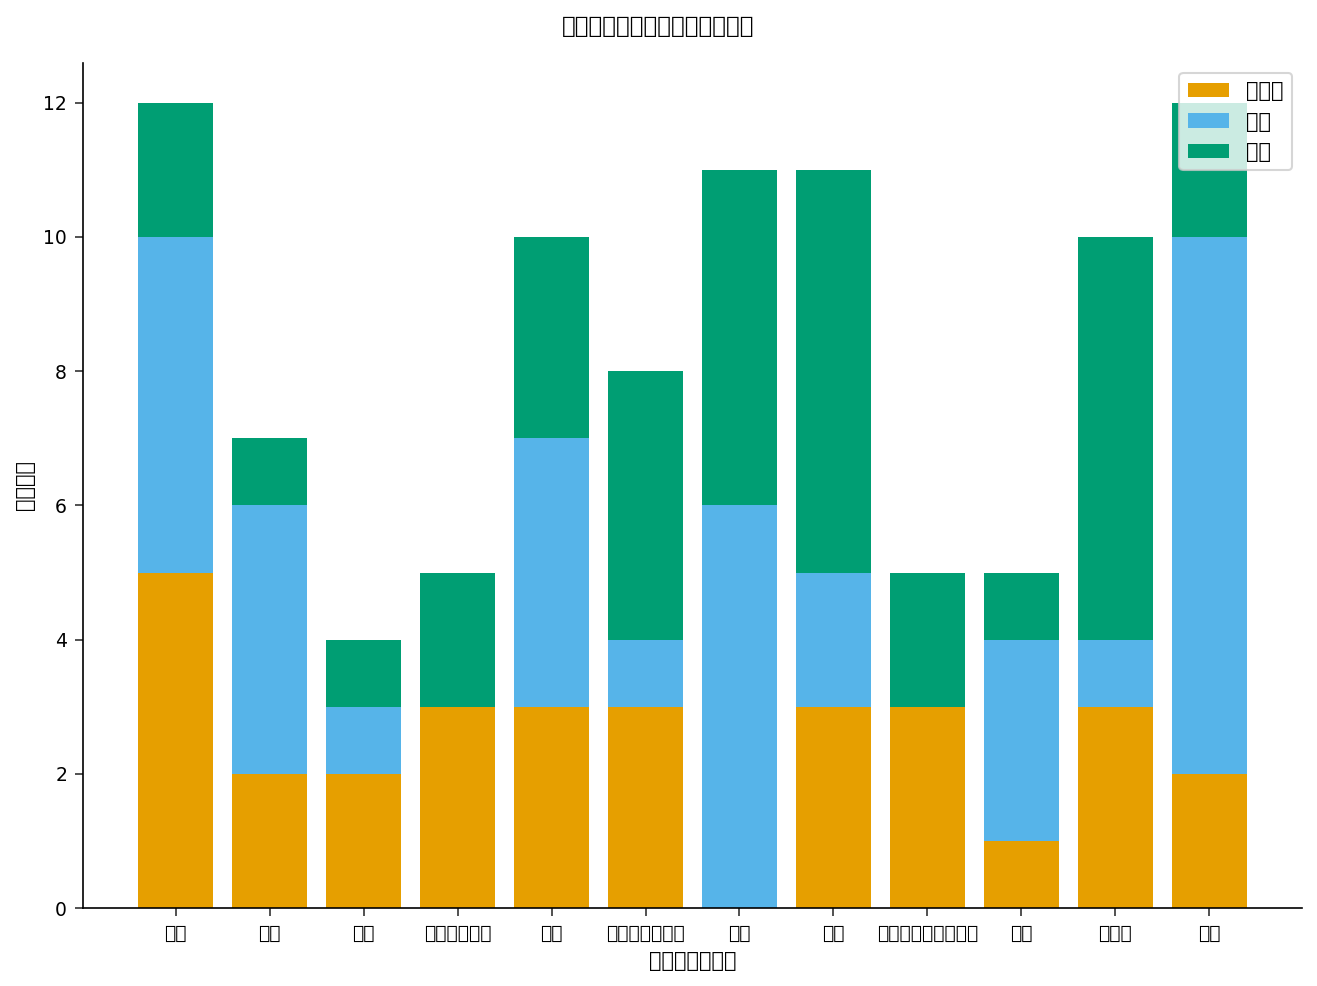

In [4]:
/* --------------------------------------------------------
   AE severity distribution by preferred term
   -------------------------------------------------------- */
処理 SGPLOT データ=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    見出 aedecod = "有害事象基本語 (PT)" aesev = "重症度";
    XAXIS 見出='有害事象基本語' fitpolicy=ROTATE;
    YAXIS 見出='事象件数';
    表題 '有害事象基本語別の重症度分布';
実行;


---

In [5]:
/* --------------------------------------------------------
   Define the MedDRA preferred term -> System Organ Class
   value format. The format is keyed on the preferred-term
   text so a single PUT() call codes any AE record to its SOC.
   -------------------------------------------------------- */
処理 書式;
    VALUE $pt_to_soc
        '悪心'               = '胃腸障害'
        '嘔吐'               = '胃腸障害'
        '下痢'               = '胃腸障害'
        '腹痛'               = '胃腸障害'
        '頭痛'               = '神経系障害'
        '疲労'               = '全身障害'
        '発熱'               = '全身障害'
        '咳嗽'               = '呼吸器障害'
        '関節痛'             = '筋骨格系障害'
        '好中球減少症'         = '血液およびリンパ系障害'
        '発熱性好中球減少症'   = '血液およびリンパ系障害'
        '注入に伴う反応'       = '免疫系障害'
        OTHER                = '未コード化'
    ;
    VALUE $sev_rank
        '軽度'   = '1-軽度'
        '中等度' = '2-中等度'
        '重度'   = '3-重度'
        OTHER    = '9-不明'
    ;
    VALUE $serious_fmt
        'Y' = '重篤'
        'N' = '非重篤'
    ;
実行;



NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   AE記録に治療群を結合し、SOC書式を適用する。
   PUT(aedecod, $pt_to_soc.) が唯一のマッピング処理であり、
   重症度と重篤性も同じ方法でコード化される。
   -------------------------------------------------------- */
処理 並替 データ=work.ae_raw; 基準 usubjid; 実行;
処理 並替 データ=work.randomization; 基準 usubjid; 実行;

データ work.ae_coded;
    長さ soc_class $40 severity_rank $16 serious_flag $12;
    結合 work.ae_raw (IN=a)
          work.randomization (IN=b 保持=usubjid treatment_arm);
    基準 usubjid;
    もし a;
    soc_class     = PUT(aedecod, $pt_to_soc.);
    severity_rank = PUT(aesev,   $sev_rank.);
    serious_flag  = PUT(aeser,   $serious_fmt.);
実行;



NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


                                                 臓器別大分類および治療群別の有害事象発現率                                                  

                                                   The FREQ Procedure

Table of 臓器別大分類 (SOC) by 治療群

臓器別大分類 (SOC)                      |          プラセボ群 |          実薬対照群 |           治験薬群 |           Total
----------------------------------+----------------+----------------+----------------+----------------
免疫系障害                             |              1 |              0 |              1 |               2
----------------------------------+----------------+----------------+----------------+----------------
全身障害                              |              3 |              1 |              1 |               5
----------------------------------+----------------+----------------+----------------+----------------
胃腸障害                              |              2 |              1 |              0 |               3
----------------------------------+----------------+----


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


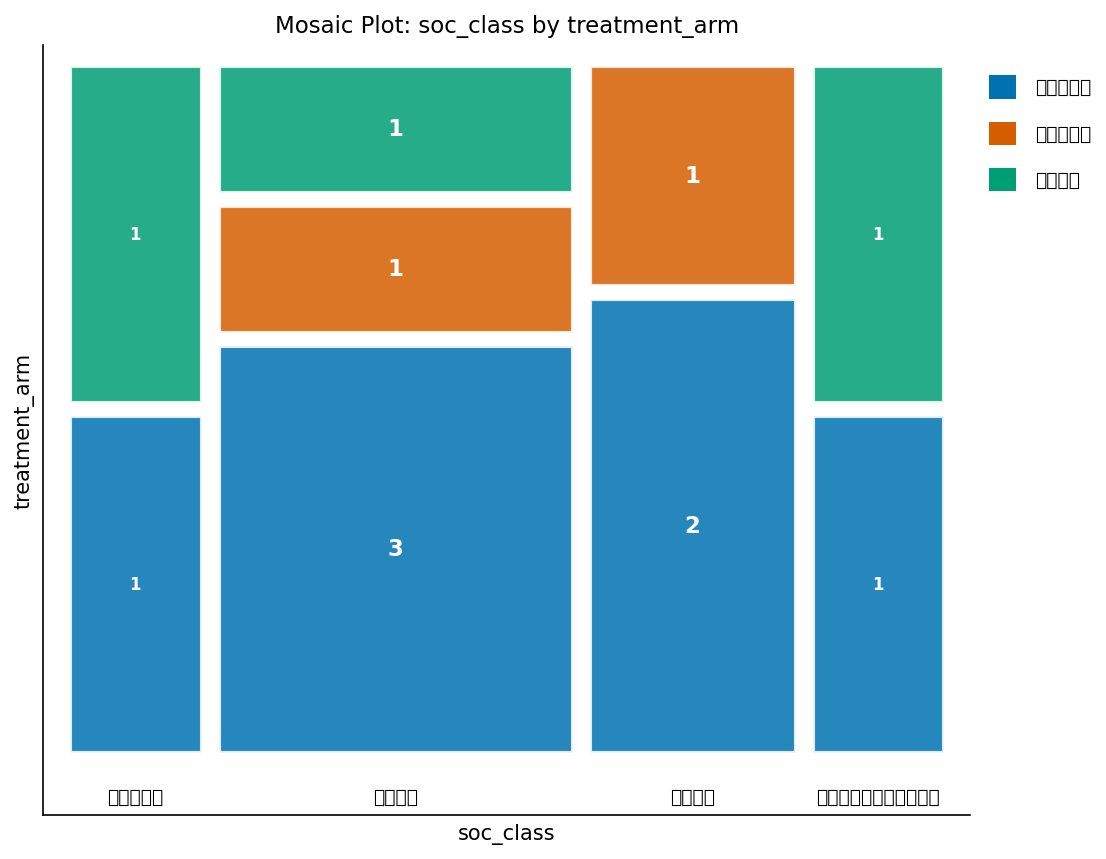

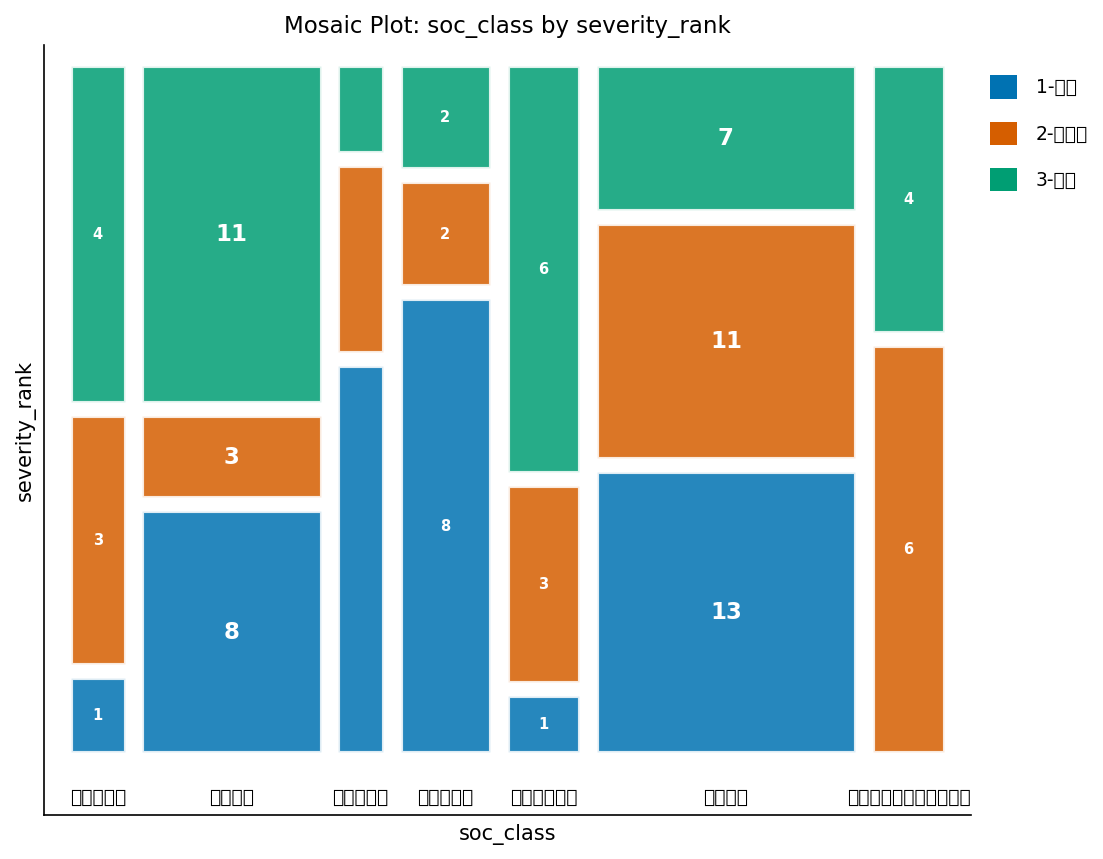

In [7]:
/* --------------------------------------------------------
   SOC別の治療群別頻度
   ODSでシグナル検出用の結果を出力する
   -------------------------------------------------------- */
ODS 出力 onewayfreqs=work.soc_freq_table;

処理 度数 データ=work.ae_coded ORDER=度数;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    見出 soc_class="臓器別大分類 (SOC)" treatment_arm="治療群" severity_rank="重症度ランク";
    表題 '臓器別大分類および治療群別の有害事象発現率';
実行;

ODS 出力 CLOSE;


                                                  臓器別大分類および治療群別の重篤有害事象                                                  

                                                   The FREQ Procedure

Table of 臓器別大分類 (SOC) by 治療群

臓器別大分類 (SOC)             |          プラセボ群 |          実薬対照群 |           治験薬群 |           Total
-------------------------+----------------+----------------+----------------+----------------
免疫系障害                    |              1 |              0 |              0 |               1
-------------------------+----------------+----------------+----------------+----------------
全身障害                     |              1 |              1 |              1 |               3
-------------------------+----------------+----------------+----------------+----------------
Total                    |              2 |              1 |              1 |               4




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


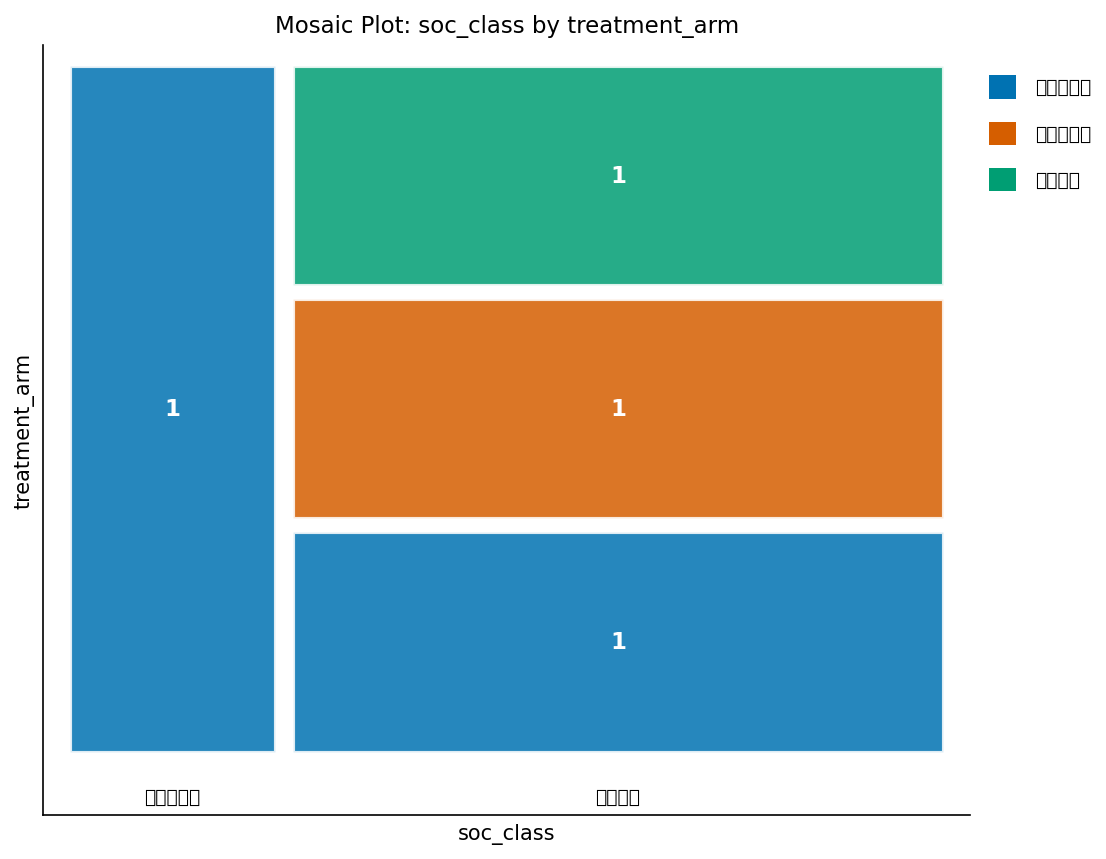

In [8]:
/* --------------------------------------------------------
   安全性所見のためのSOC別重篤有害事象サマリー
   -------------------------------------------------------- */
処理 度数 データ=work.ae_coded;
    条件 aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    見出 soc_class="臓器別大分類 (SOC)" treatment_arm="治療群";
    表題 '臓器別大分類および治療群別の重篤有害事象';
実行;


---

### 解釈

単一の `$pt_to_soc` 値書式が、12種類の逐語的なMedDRA基本語から全100件の有害事象を7つの臓器別大分類（SOC）にコード化し、その1つの書式が以下の全テーブルをデータの再コード化なしに駆動した。

SOCおよび重症度別に見ると、**胃腸障害**が31/100件で最も頻度の高いクラスであり（軽度13件、中等度11件、重度7件）、次いで**全身障害**が22件で続く。残りのクラスはより小さい：神経系障害（12件）、血液およびリンパ系障害（10件）、筋骨格系障害（10件）、免疫系障害（8件）、呼吸器障害（7件）。全事象を通じた重症度の内訳は軽度35件、中等度30件、重度35件である。

重篤（`aeser='Y'`）とフラグされたのは4件のみであった：全身障害で3件（各群1件ずつ）、免疫系障害で1件（プラセボ群）。SOC×治療群のクロス集計は、被験者が無作為化記録と一致した12件の事象から構築されているため、群別件数は群間比較のための検出力を持つものではなく、あくまで例示にすぎない。

重要な要点は合成データの数値そのものではなくFORMATの仕組みである：基本語からSOCへのマッピングがPROC FORMATに完全に集約されているため、同じ `PUT(aedecod, $pt_to_soc.)` 呼び出しがデータセット全体を再格付けし、新しいMedDRA辞書バージョンへの更新はすべてのレポートを書き直すのではなく1つの書式を編集するだけで済む。ODS OUTPUTは後続のシグナルレビュー用にSOC別頻度を `work.soc_freq_table` として取得した。


---

In [9]:
/* --------------------------------------------------------
   安全性シグナルレビュー用にSOCコード化済みAEデータセットを
   出力する。単一の$pt_to_soc書式によりsoc_classが設定済みの
   ため、出力ファイルはSOCレベル分析にそのまま使用できる。
   -------------------------------------------------------- */
処理 EXPORT データ=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
実行;



NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供： <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>